# 3K FRET analysis

Three channels — **orange** = acceptor / lipid droplets · **green** = donor / synuclein inclusions · **blue** = FRET channel.

Green and blue inclusion masks use the **same function and parameters**, with the same adaptive threshold rule applied separately to each channel. All MFIs use untouched raw pixels; normalization is used only for segmentation and display.

- **Structure spreadsheet:** one row per green inclusion, matched one-to-one to blue by filled-mask IoU (minimum 0.05). `Blue_Narrower_Than_Green` compares the maximum inscribed widths of the largest enclosed holes. True means the blue hole is narrower; False means equal or wider. A missing match or measurable hole leaves the result blank with `Comparison_Valid = False` and a reason. Open edge gaps are not holes.
- **Orange inside green:** retain whole droplets with at least 50% of their area inside one filled green inclusion. The measurement mask is retained-orange AND the union of filled green inclusions AND the individual cell mask. Filling includes an inclusion's interior, so enclosed droplets are measurable even where green fluorescence is dim.
- **Cell spreadsheet:** one row per segmented cell, with orange, green, and blue raw MFIs over that exact same measurement mask. Empty masks give NaN (blank in Excel), not zero. Relative-to-image-mean columns are separate optional ratios.
- **Green surrounding orange:** check every orange droplet. Contact means at least 3 green-wall pixels in its 2-pixel exterior ring. Retain every contacting green structure. `Green_Surrounding_Orange_MFI_raw` measures their full fluorescent walls within each cell; `Green_Orange_Contact_MFI_raw` measures only their local contact pixels.

Hole widths describe the segmented geometry and depend on the masks. Identical adaptive settings do not imply identical absolute intensity cutoffs across channels.

## Imports

In [1]:
%matplotlib inline
import os
import glob
import warnings
from pathlib import Path

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import czifile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from scipy import ndimage as ndi
from scipy.optimize import linear_sum_assignment
from skimage import exposure, morphology
from skimage.filters import gaussian, threshold_otsu
from skimage.measure import label, regionprops
from skimage.segmentation import find_boundaries, relabel_sequential, watershed


## Parameters & segmentation method

In [2]:
CHANNEL_ORDER = {"orange": 0, "green": 1, "blue": 2}

# ---- Green/blue inclusion masks (identical parameters for both channels) ----
INCL_NORM_LOW = 1.0
INCL_NORM_HIGH = 99.7
INCL_TOPHAT_RADIUS = 18
INCL_PRESMOOTH_SIGMA = 0.7
INCL_TOPHAT_FLOOR = 0.060
INCL_MIN_BRIGHTNESS = 0.120
INCL_LOCAL_ZSCORE = 1.0
INCL_LOCAL_PCTL = 90.0
INCL_PROMINENCE_MULT = 4.0
INCL_MIN_WALL_AREA = 24
INCL_MAX_FILLED_AREA = 12_000
INCL_MIN_OBJECT_RADIUS = 2.5
INCL_STRAND_MIN_MAJOR_AXIS = 40.0
INCL_MAX_AXIS_RATIO = 6.5
INCL_CLOSING_RADIUS = 5
INCL_WATERSHED_H = 3.0
INCL_MIN_HOLE_AREA = 8
INCL_HOLE_REL_DROP = 0.85       # hole = dimmer than 85% of its own wall's median
INCL_HOLE_INTERIOR_ERODE = 2    # px trimmed before the hole search, so an
                                # object's dim outer margin is not read as a hole
INCL_MIN_MATCH_IOU = 0.05

# ---- Orange lipid-droplet mask ----
ORANGE_TOPHAT_RADIUS = 10
ORANGE_LOCAL_PCTL = 98.5
ORANGE_MAD_MULT = 6.0
ORANGE_MIN_PROMINENCE = 500.0
ORANGE_MIN_AREA = 6
ORANGE_MAX_AREA = 2_000
ORANGE_CLOSING_RADIUS = 1
ORANGE_MIN_FRACTION_INSIDE_GREEN = 0.50
ORANGE_CONTACT_RADIUS = 2
ORANGE_MIN_CONTACT_AREA = 3

# ---- Whole-cell segmentation (Cellpose cyto3 on the green+blue composite) ----
CELL_DIAMETER = 250.0
CELL_SMOOTH_SIGMA = 3.0
CELL_FLOW_THRESH = 0.9
CELL_PROB_THRESH = -1.0
CELL_MIN_AREA = 3_000
CELL_MIN_MEAN_SIGNAL = 0.10
CELL_DIM_MIN_MEAN_SIGNAL = 0.045
CELL_DIM_HALO = 8


STRUCTURE_COLUMNS = [
    "Image",
    "Green_Inclusion_ID",
    "Cell_ID",
    "Green_Filled_Area_px",
    "Green_Wall_Area_px",
    "Green_Hole_Area_px",
    "Green_Structure_Max_Inscribed_Width_px",
    "Green_Hole_Equivalent_Diameter_px",
    "Green_Hole_Max_Inscribed_Width_px",
    "Matched_Blue_Inclusion_ID",
    "Green_Blue_Overlap_Area_px",
    "Green_Blue_IoU",
    "Green_Blue_Match_IoU",
    "Blue_Filled_Area_px",
    "Blue_Wall_Area_px",
    "Blue_Hole_Area_px",
    "Blue_Structure_Max_Inscribed_Width_px",
    "Blue_Hole_Equivalent_Diameter_px",
    "Blue_Hole_Max_Inscribed_Width_px",
    "Comparison_Valid",
    "Blue_Narrower_Than_Green",
    "Comparison_Reason",
]


CELL_COLUMNS = [
    "Image",
    "Cell_ID",
    "Cell_Area_px",
    "N_Green_Inclusions",
    "N_Blue_Inclusions",
    "N_Orange_Lipid_Droplets",
    "N_Orange_Droplets_In_Green",
    "Orange_Droplet_In_Green_Area_px",
    "Orange_Green_Intersection_Area_px",
    "Orange_MFI_raw_Under_OrangeGreen_Intersection",
    "Green_MFI_raw_Under_OrangeGreen_Intersection",
    "Blue_MFI_raw_Under_OrangeGreen_Intersection",
    "Image_Mean_Orange_raw",
    "Image_Mean_Green_raw",
    "Image_Mean_Blue_raw",
    "Orange_MFI_Relative_to_Image_Mean",
    "Green_MFI_Relative_to_Image_Mean",
    "Blue_MFI_Relative_to_Image_Mean",
    "N_Green_Inclusions_Surrounding_Orange",
    "Green_Surrounding_Structure_Area_px",
    "Green_Surrounding_Orange_MFI_raw",
    "Green_Orange_Contact_Area_px",
    "Green_Orange_Contact_MFI_raw",
]


# ---- Run settings ----
BASE_DIR = "."
IMAGE_FOLDER_NAMES = ["test images"]


def resolve_image_folder(name):
    """Return the first existing path for `name` (bare or under images/)."""
    for cand in (os.path.join(BASE_DIR, name), os.path.join(BASE_DIR, "images", name)):
        if os.path.isdir(cand):
            return cand
    return os.path.join(BASE_DIR, name)


IMAGE_FOLDERS = [resolve_image_folder(n) for n in IMAGE_FOLDER_NAMES]
FILE_EXTENSION = "*.czi"
RESULTS_FOLDER = "Results"
MASK_FOLDER = os.path.join(RESULTS_FOLDER, "masks")

USE_CELLPOSE = True
USE_GPU = True
SHOW_PLOTS = True  # show the QC panels inline for each image


## Loading & normalization

In [3]:
def percentile_normalize(image, low=1.0, high=99.7):
    """Return a clipped float32 segmentation copy in [0, 1]."""

    values = image.astype(np.float32, copy=False)
    p_low, p_high = np.percentile(values, (low, high))
    if p_high <= p_low:
        return np.zeros_like(values, dtype=np.float32)
    return np.clip((values - p_low) / (p_high - p_low), 0.0, 1.0)


def display_normalize(image):
    """Contrast stretch used only for QC plots."""

    p_low, p_high = np.percentile(image, (1.0, 99.7))
    if p_high <= p_low:
        return np.zeros_like(image, dtype=np.float32)
    return exposure.rescale_intensity(
        image, in_range=(p_low, p_high), out_range=(0.0, 1.0)
    ).astype(np.float32)


def load_three_channel_czi(path):
    """Load a CZI and return three untouched 2-D channel arrays."""

    array = np.squeeze(czifile.imread(str(path)))
    if array.ndim != 3:
        raise ValueError(
            f"{path.name}: expected a squeezed 3-D array, received shape {array.shape}"
        )

    channel_axes = [axis for axis, size in enumerate(array.shape) if size == 3]
    if not channel_axes:
        raise ValueError(
            f"{path.name}: no three-channel axis was found in shape {array.shape}"
        )
    array = np.moveaxis(array, channel_axes[0], 0)
    if array.shape[0] != 3:
        raise ValueError(
            f"{path.name}: expected exactly three channels, received shape {array.shape}"
        )

    raw = {name: array[index] for name, index in CHANNEL_ORDER.items()}
    spatial_shapes = {channel.shape for channel in raw.values()}
    if len(spatial_shapes) != 1:
        raise ValueError(f"{path.name}: channel shapes differ: {sorted(spatial_shapes)}")
    return raw


def _drop_small_labels(labels, minimum_area):
    output = labels.astype(np.int32, copy=True)
    counts = np.bincount(output.ravel())
    small_ids = np.flatnonzero(counts < minimum_area)
    small_ids = small_ids[small_ids != 0]
    if small_ids.size:
        output[np.isin(output, small_ids)] = 0
    return relabel_sequential(output)[0].astype(np.int32)


def _remove_small_binary_objects(mask, minimum_area):
    """Version-stable removal of connected components smaller than minimum_area."""

    labels = label(mask)
    if int(labels.max()) == 0:
        return mask.astype(bool, copy=True)
    counts = np.bincount(labels.ravel())
    small_ids = np.flatnonzero(counts < minimum_area)
    small_ids = small_ids[small_ids != 0]
    if not small_ids.size:
        return mask.astype(bool, copy=True)
    return mask & ~np.isin(labels, small_ids)


def _enclosed_hole_mask(object_mask, wall_mask, minimum_area):
    """Keep only non-wall pixels enclosed by this object's fluorescent wall."""

    wall = object_mask & wall_mask
    # Use 8-connected background so even a diagonal opening is not a hole.
    enclosed = ndi.binary_fill_holes(wall, structure=np.ones((3, 3), bool))
    holes = enclosed & object_mask & ~wall
    return _remove_small_binary_objects(holes, minimum_area)


## Mask functions

In [4]:
# Cellpose cyto3 model, created once (None disables it -> intensity fallback).
if USE_CELLPOSE:
    from cellpose import models
    cyto_model = models.Cellpose(gpu=USE_GPU, model_type="cyto3")
else:
    cyto_model = None


def _gate_cellpose_labels(masks, composite, minimum_signal):
    output = masks.astype(np.int32, copy=True)
    for region in regionprops(output):
        selected = output == region.label
        if (
            region.area < CELL_MIN_AREA
            or float(composite[selected].mean()) < minimum_signal
        ):
            output[selected] = 0
    return relabel_sequential(output)[0].astype(np.int32)


def _run_cellpose(image):
    result = cyto_model.eval(
        image,
        diameter=CELL_DIAMETER,
        channels=[0, 0],
        flow_threshold=CELL_FLOW_THRESH,
        cellprob_threshold=CELL_PROB_THRESH,
        normalize=True,
        resample=True,
    )
    return np.asarray(result[0], dtype=np.int32)


def _segment_cells_intensity(composite):
    """Conservative fallback when Cellpose is unavailable or disabled."""

    smoothed = gaussian(composite, sigma=10.0)
    try:
        threshold = max(float(threshold_otsu(smoothed)), 0.05)
    except ValueError:
        threshold = 0.05
    foreground = smoothed > threshold
    foreground = _remove_small_binary_objects(
        foreground, CELL_MIN_AREA
    )
    foreground = ndi.binary_fill_holes(foreground)
    return _drop_small_labels(label(foreground), CELL_MIN_AREA)


def segment_cells(green_raw, blue_raw):
    """Segment whole cells from the max of normalized green and blue channels."""

    green = percentile_normalize(green_raw, 1.0, 99.5)
    blue = percentile_normalize(blue_raw, 1.0, 99.5)
    composite = np.maximum(green, blue)

    if cyto_model is None:
        return _segment_cells_intensity(composite), composite

    prepared = gaussian(composite, sigma=CELL_SMOOTH_SIGMA)
    bright = _gate_cellpose_labels(
        _run_cellpose(prepared),
        composite,
        CELL_MIN_MEAN_SIGNAL,
    )
    combined = bright.copy()
    next_label = int(combined.max())

    leftover = composite.copy()
    halo = morphology.dilation(
        bright > 0, morphology.disk(CELL_DIM_HALO)
    )
    leftover[halo] = 0
    positive = leftover[leftover > 0]
    if positive.size > 50:
        p_low, p_high = np.percentile(positive, (1.0, 99.5))
        if p_high > p_low:
            restretched = np.clip(
                (leftover - p_low) / (p_high - p_low), 0.0, 1.0
            )
            dim = _gate_cellpose_labels(
                _run_cellpose(
                    gaussian(restretched, sigma=CELL_SMOOTH_SIGMA),
                ),
                composite,
                CELL_DIM_MIN_MEAN_SIGNAL,
            )
            for region in regionprops(dim):
                selected = (dim == region.label) & (bright == 0)
                if (
                    int(selected.sum()) >= CELL_MIN_AREA
                    and float(composite[selected].mean())
                    >= CELL_DIM_MIN_MEAN_SIGNAL
                ):
                    next_label += 1
                    combined[selected] = next_label

    combined = _drop_small_labels(combined, CELL_MIN_AREA)
    return combined, composite


def _split_touching_objects(mask, h_value):
    """Watershed can split touching objects but never joins separate objects."""

    if not mask.any():
        return np.zeros(mask.shape, dtype=np.int32)
    distance = ndi.distance_transform_edt(mask)
    markers = label(morphology.h_maxima(distance, h_value))
    if int(markers.max()) == 0:
        return label(mask).astype(np.int32)
    return watershed(-distance, markers, mask=mask).astype(np.int32)


def _merge_fragments_across_cells(objects, labeled_cells):
    """Rejoin one structure that the per-cell clipping cut at a cell border.

    Objects are sealed and filled one cell at a time, so a structure lying
    across a border becomes two labels and two spreadsheet rows. Fragments that
    touch across a cell border are merged; fragments touching inside a single
    cell are left alone, because those are genuine watershed splits.
    """

    maximum = int(objects.max())
    if maximum == 0:
        return objects
    parent = np.arange(maximum + 1)

    def find(node):
        while parent[node] != node:
            parent[node] = parent[parent[node]]
            node = parent[node]
        return node

    for axis in (0, 1):
        lower, upper = [slice(None)] * 2, [slice(None)] * 2
        lower[axis], upper[axis] = slice(0, -1), slice(1, None)
        left, right = objects[tuple(lower)], objects[tuple(upper)]
        cell_left, cell_right = labeled_cells[tuple(lower)], labeled_cells[tuple(upper)]
        touching = (
            (left > 0) & (right > 0) & (left != right) & (cell_left != cell_right)
        )
        for one, two in zip(left[touching], right[touching]):
            root_one, root_two = find(int(one)), find(int(two))
            if root_one != root_two:
                parent[max(root_one, root_two)] = min(root_one, root_two)

    remap = np.array([find(index) for index in range(maximum + 1)], dtype=np.int32)
    remap[0] = 0
    return relabel_sequential(remap[objects])[0].astype(np.int32)


def _fill_and_label_inclusions(wall_mask, labeled_cells):
    """Seal, fill, split, and label inclusions independently inside each cell."""

    objects = np.zeros(wall_mask.shape, dtype=np.int32)
    retained_wall = np.zeros(wall_mask.shape, dtype=bool)
    next_label = 0

    for cell_id in range(1, int(labeled_cells.max()) + 1):
        cell = labeled_cells == cell_id
        cell_wall = wall_mask & cell
        if not cell_wall.any():
            continue
        closed = morphology.closing(
            cell_wall, morphology.disk(INCL_CLOSING_RADIUS)
        ) & cell
        filled = ndi.binary_fill_holes(closed) & cell
        filled = _remove_small_binary_objects(
            filled, INCL_MIN_WALL_AREA
        )
        cell_objects = _split_touching_objects(
            filled, INCL_WATERSHED_H
        )
        for region in regionprops(cell_objects):
            selected = cell_objects == region.label
            object_radius = float(ndi.distance_transform_edt(selected).max())
            minor_axis = max(float(region.axis_minor_length), 1e-6)
            axis_ratio = float(region.axis_major_length) / minor_axis
            # Both length and elongation are required so compact inclusions remain.
            is_long_strand = (
                float(region.axis_major_length) >= INCL_STRAND_MIN_MAJOR_AXIS
                and axis_ratio >= INCL_MAX_AXIS_RATIO
            )
            if (
                region.area > INCL_MAX_FILLED_AREA
                or object_radius < INCL_MIN_OBJECT_RADIUS
                or is_long_strand
            ):
                cell_objects[selected] = 0
        cell_objects = relabel_sequential(cell_objects)[0].astype(np.int32)
        for object_id in range(1, int(cell_objects.max()) + 1):
            next_label += 1
            objects[cell_objects == object_id] = next_label
        retained_wall |= cell_wall & (cell_objects > 0)

    objects = _merge_fragments_across_cells(objects, labeled_cells)
    return objects, retained_wall


def _refine_holes(normalized, objects, wall, minimum_area):
    """Return enclosed holes and walls after re-reading dim interiors.

    The wall threshold comes from whole-cell statistics, so inside a bright
    inclusion the dark centre still clears it and is wrongly kept as wall. Each
    object is therefore re-examined against its own wall brightness. Eroding
    first keeps an object's dim outer margin from reading as a hole.
    """

    holes = _remove_small_binary_objects((objects > 0) & ~wall, minimum_area)
    interior_element = morphology.disk(INCL_HOLE_INTERIOR_ERODE)
    for object_id in range(1, int(objects.max()) + 1):
        selected = objects == object_id
        wall_values = normalized[selected & wall]
        if wall_values.size == 0:
            continue
        interior = morphology.erosion(selected, interior_element)
        if not interior.any():
            continue
        candidate = interior & (
            normalized <= float(np.median(wall_values)) * INCL_HOLE_REL_DROP
        )
        if not candidate.any():
            continue
        holes |= _remove_small_binary_objects(candidate, minimum_area)
    # Exclude outer margins and open gaps; use this same topology for metrics.
    refined_wall = wall & ~holes
    enclosed = np.zeros_like(holes)
    for object_id in range(1, int(objects.max()) + 1):
        enclosed |= _enclosed_hole_mask(
            objects == object_id, refined_wall, minimum_area
        )
    return enclosed, refined_wall


def segment_inclusion_channel(raw_channel, labeled_cells):
    """Create wall, filled-object, and hole masks for green OR blue.

    This exact function and the same shared INCL_* constants are used for both
    channels. Channel-specific thresholds are intentionally not allowed.
    """

    normalized = percentile_normalize(
        raw_channel,
        INCL_NORM_LOW,
        INCL_NORM_HIGH,
    )
    tophat = morphology.white_tophat(
        normalized, morphology.disk(INCL_TOPHAT_RADIUS)
    )
    if INCL_PRESMOOTH_SIGMA > 0:
        tophat = gaussian(tophat, sigma=INCL_PRESMOOTH_SIGMA)

    wall = np.zeros(raw_channel.shape, dtype=bool)
    for cell_id in range(1, int(labeled_cells.max()) + 1):
        cell = labeled_cells == cell_id
        values = tophat[cell]
        if values.size == 0:
            continue
        standard_deviation = max(float(values.std()), 1e-6)
        local_threshold = max(
            INCL_TOPHAT_FLOOR,
            float(values.mean()) + INCL_LOCAL_ZSCORE * standard_deviation,
            float(np.percentile(values, INCL_LOCAL_PCTL)),
            INCL_PROMINENCE_MULT * float(np.median(values)),
        )
        wall |= (
            cell
            & (tophat >= local_threshold)
            & (normalized >= INCL_MIN_BRIGHTNESS)
        )

    wall = _remove_small_binary_objects(
        wall, INCL_MIN_WALL_AREA
    )
    objects, wall = _fill_and_label_inclusions(wall, labeled_cells)
    # Holes are judged against each object's own wall brightness, so a dark
    # centre inside a bright inclusion is no longer absorbed into the wall.
    holes, wall = _refine_holes(normalized, objects, wall, INCL_MIN_HOLE_AREA)
    return {
        "normalized": normalized,
        "tophat": tophat,
        "wall": wall,
        "objects": objects,
        "filled": objects > 0,
        "holes": holes,
    }


def segment_orange_droplets(orange_raw, labeled_cells):
    """Segment bright orange lipid droplets with per-cell robust thresholds."""

    raw_float = orange_raw.astype(np.float32, copy=False)
    tophat = morphology.white_tophat(
        raw_float, morphology.disk(ORANGE_TOPHAT_RADIUS)
    )
    mask = np.zeros(orange_raw.shape, dtype=bool)

    for cell_id in range(1, int(labeled_cells.max()) + 1):
        cell = labeled_cells == cell_id
        values = tophat[cell]
        if values.size == 0:
            continue
        median = float(np.median(values))
        mad = float(np.median(np.abs(values - median)))
        robust_sigma = max(1.5 * mad, 1.0)
        threshold = max(
            ORANGE_MIN_PROMINENCE,
            median + ORANGE_MAD_MULT * robust_sigma,
            float(np.percentile(values, ORANGE_LOCAL_PCTL)),
        )
        mask |= cell & (tophat >= threshold)

    objects = np.zeros(mask.shape, dtype=np.int32)
    next_label = 0
    for cell_id in range(1, int(labeled_cells.max()) + 1):
        cell = labeled_cells == cell_id
        cleaned = morphology.closing(
            mask & cell, morphology.disk(ORANGE_CLOSING_RADIUS)
        ) & cell
        cleaned = _remove_small_binary_objects(
            cleaned, ORANGE_MIN_AREA
        )
        cell_objects = label(cleaned)
        for region in regionprops(cell_objects):
            if region.area > ORANGE_MAX_AREA:
                cell_objects[cell_objects == region.label] = 0
        cell_objects = relabel_sequential(cell_objects)[0].astype(np.int32)
        for object_id in range(1, int(cell_objects.max()) + 1):
            next_label += 1
            objects[cell_objects == object_id] = next_label
    return objects


## Overlap helpers

In [5]:
def _largest_hole_metrics(object_mask, wall_mask, minimum_area):
    """Measure the largest enclosed non-wall region of one inclusion."""

    hole_labels = label(_enclosed_hole_mask(object_mask, wall_mask, minimum_area))
    candidates = [
        region for region in regionprops(hole_labels) if region.area >= minimum_area
    ]
    if not candidates:
        return {
            "area": 0.0,
            "max_width": np.nan,
            "equivalent_diameter": np.nan,
        }
    largest = max(candidates, key=lambda region: region.area)
    hole = hole_labels == largest.label
    max_width = 2.0 * float(ndi.distance_transform_edt(hole).max())
    equivalent_diameter = 2.0 * np.sqrt(float(largest.area) / np.pi)
    return {
        "area": float(largest.area),
        "max_width": max_width,
        "equivalent_diameter": equivalent_diameter,
    }


def _max_inscribed_structure_width(structure_mask):
    """Return the full diameter of the largest disk inside a structure."""

    if not structure_mask.any():
        return np.nan
    # Distance-transform width measures geometry, not object area or length.
    return 2.0 * float(ndi.distance_transform_edt(structure_mask).max())


def _object_cell_id(object_mask, labeled_cells):
    values = labeled_cells[object_mask]
    values = values[values > 0]
    if values.size == 0:
        return 0
    counts = np.bincount(values)
    return int(np.argmax(counts))


def match_green_and_blue_inclusions(image_name, green_objects, green_wall, blue_objects, blue_wall, labeled_cells):
    """Match objects one-to-one by IoU and create one record per green object."""

    green_ids = np.arange(1, int(green_objects.max()) + 1, dtype=int)
    blue_ids = np.arange(1, int(blue_objects.max()) + 1, dtype=int)
    iou = np.zeros((len(green_ids), len(blue_ids)), dtype=float)
    overlaps = np.zeros_like(iou, dtype=int)

    green_areas = {
        object_id: int((green_objects == object_id).sum())
        for object_id in green_ids
    }
    blue_areas = {
        object_id: int((blue_objects == object_id).sum())
        for object_id in blue_ids
    }
    for green_index, green_id in enumerate(green_ids):
        green = green_objects == green_id
        overlapping_blue = np.unique(blue_objects[green])
        for blue_id in overlapping_blue[overlapping_blue > 0]:
            blue_index = int(blue_id - 1)
            overlap = int((green & (blue_objects == blue_id)).sum())
            union = green_areas[int(green_id)] + blue_areas[int(blue_id)] - overlap
            overlaps[green_index, blue_index] = overlap
            iou[green_index, blue_index] = overlap / union if union else 0.0

    matches = {}
    match_ious = {}
    if iou.size:
        green_indices, blue_indices = linear_sum_assignment(-iou)
        for green_index, blue_index in zip(green_indices, blue_indices):
            if iou[green_index, blue_index] >= INCL_MIN_MATCH_IOU:
                matches[int(green_ids[green_index])] = int(blue_ids[blue_index])
                match_ious[int(green_ids[green_index])] = float(
                    iou[green_index, blue_index]
                )

    records = []
    for green_id in green_ids:
        green = green_objects == green_id
        green_structure = green & green_wall
        green_width = _max_inscribed_structure_width(green_structure)
        green_hole = _largest_hole_metrics(
            green, green_wall, INCL_MIN_HOLE_AREA
        )
        blue_id = matches.get(int(green_id))
        comparison_valid = False
        # Left blank rather than False so an invalid row cannot be miscounted
        # as a real "not narrower" answer in the spreadsheet.
        narrower = None
        reason = "No overlapping blue inclusion met the minimum IoU"
        blue_area = np.nan
        blue_wall_area = np.nan
        blue_width = np.nan
        blue_hole = {
            "area": np.nan,
            "max_width": np.nan,
            "equivalent_diameter": np.nan,
        }
        overlap_area = 0
        match_iou = np.nan

        if blue_id is not None:
            blue = blue_objects == blue_id
            blue_structure = blue & blue_wall
            blue_area = int(blue.sum())
            blue_wall_area = int(blue_structure.sum())
            blue_width = _max_inscribed_structure_width(blue_structure)
            blue_hole = _largest_hole_metrics(
                blue, blue_wall, INCL_MIN_HOLE_AREA
            )
            overlap_area = int((green_structure & blue_structure).sum())
            union_area = int((green_structure | blue_structure).sum())
            match_iou = overlap_area / union_area if union_area else np.nan
            if not np.isfinite(green_hole["max_width"]):
                reason = "Green inclusion has no measurable hole"
            elif not np.isfinite(blue_hole["max_width"]):
                reason = "Blue inclusion has no measurable hole"
            else:
                comparison_valid = True
                narrower = bool(blue_hole["max_width"] < green_hole["max_width"])
                reason = "Compared maximum inscribed hole widths"

        records.append(
            {
                "Image": image_name,
                "Green_Inclusion_ID": int(green_id),
                "Cell_ID": _object_cell_id(green, labeled_cells),
                "Green_Filled_Area_px": int(green.sum()),
                "Green_Wall_Area_px": int(green_structure.sum()),
                "Green_Hole_Area_px": int(green_hole["area"]),
                "Green_Structure_Max_Inscribed_Width_px": green_width,
                "Green_Hole_Equivalent_Diameter_px": green_hole[
                    "equivalent_diameter"
                ],
                "Green_Hole_Max_Inscribed_Width_px": green_hole["max_width"],
                "Matched_Blue_Inclusion_ID": blue_id,
                "Green_Blue_Overlap_Area_px": overlap_area,
                "Green_Blue_IoU": match_iou,
                "Green_Blue_Match_IoU": match_ious.get(int(green_id), np.nan),
                "Blue_Filled_Area_px": blue_area,
                "Blue_Wall_Area_px": blue_wall_area,
                "Blue_Hole_Area_px": blue_hole["area"],
                "Blue_Structure_Max_Inscribed_Width_px": blue_width,
                "Blue_Hole_Equivalent_Diameter_px": blue_hole[
                    "equivalent_diameter"
                ],
                "Blue_Hole_Max_Inscribed_Width_px": blue_hole["max_width"],
                "Comparison_Valid": comparison_valid,
                "Blue_Narrower_Than_Green": narrower,
                "Comparison_Reason": reason,
            }
        )
    return records, matches


def find_orange_droplets_inside_green(orange_objects, green_objects):
    """Retain whole orange droplets whose area is at least 50% inside green."""

    included = np.zeros(orange_objects.shape, dtype=bool)
    intersection = np.zeros(orange_objects.shape, dtype=bool)
    orange_to_green = {}
    inclusion_fractions = {}

    for orange_id in range(1, int(orange_objects.max()) + 1):
        droplet = orange_objects == orange_id
        droplet_area = int(droplet.sum())
        overlapping_green = np.unique(green_objects[droplet])
        overlapping_green = overlapping_green[overlapping_green > 0]
        if droplet_area == 0 or overlapping_green.size == 0:
            continue
        overlap_counts = {
            int(green_id): int((droplet & (green_objects == green_id)).sum())
            for green_id in overlapping_green
        }
        green_id = max(overlap_counts, key=overlap_counts.get)
        fraction = overlap_counts[green_id] / droplet_area
        inclusion_fractions[orange_id] = fraction
        if fraction >= ORANGE_MIN_FRACTION_INSIDE_GREEN:
            included[droplet] = True
            intersection[droplet & (green_objects > 0)] = True
            orange_to_green[orange_id] = green_id

    return included, intersection, orange_to_green, inclusion_fractions


def find_green_structures_surrounding_orange(orange_objects, green_objects, green_wall):
    """Mark every green wall that touches the exterior ring of any droplet."""

    qualifying_green_ids = set()
    contact = np.zeros(orange_objects.shape, dtype=bool)
    structuring_element = morphology.disk(ORANGE_CONTACT_RADIUS)

    # Every droplet is checked, not only those already scored as inside green,
    # because the spec asks for any instance of green surrounding orange.
    for orange_id in range(1, int(orange_objects.max()) + 1):
        droplet = orange_objects == orange_id
        if not droplet.any():
            continue
        exterior_ring = morphology.dilation(
            droplet, structuring_element
        ) & ~droplet
        ring_ids = green_objects[exterior_ring & green_wall]
        ring_ids = np.unique(ring_ids[ring_ids > 0])
        if ring_ids.size == 0:
            continue
        for green_id in ring_ids:
            this_contact = exterior_ring & green_wall & (green_objects == green_id)
            if int(this_contact.sum()) >= ORANGE_MIN_CONTACT_AREA:
                qualifying_green_ids.add(int(green_id))
                contact |= this_contact

    # The spec asks for the MFI of the green *structures* that surround a
    # droplet, so this is those whole structures, not just the contact ring.
    surrounding = np.zeros(orange_objects.shape, dtype=bool)
    for green_id in qualifying_green_ids:
        surrounding |= (green_objects == green_id) & green_wall
    return surrounding, contact, qualifying_green_ids


## Per-cell analysis

In [6]:
def _raw_mean(raw, mask):
    """Mean of untouched raw pixels; blank/NaN when the mask is empty."""

    if not mask.any():
        return np.nan
    return float(raw[mask].astype(np.float64, copy=False).mean())


def _relative_mean(value, image_mean):
    if not np.isfinite(value) or image_mean == 0:
        return np.nan
    return float(value / image_mean)


def analyze_cell(cid, image_name, raw, labeled_cells, masks):
    """Return one raw-MFI row for cell `cid` (galectin-style per-cell analysis)."""
    image_means = {
        channel: float(values.astype(np.float64, copy=False).mean())
        for channel, values in raw.items()
    }
    cell = labeled_cells == cid
    measurement_mask = masks["orange_green_intersection"] & cell
    surrounding_mask = masks["green_surrounding"] & cell
    contact_mask = masks["green_contact"] & cell

    orange_mfi = _raw_mean(raw["orange"], measurement_mask)
    green_mfi = _raw_mean(raw["green"], measurement_mask)
    blue_mfi = _raw_mean(raw["blue"], measurement_mask)

    cell_orange_ids = set(np.unique(masks["orange_objects"][cell]))
    cell_orange_ids.discard(0)
    included_orange_ids = set(np.unique(masks["orange_objects"][masks["orange_in_green"] & cell]))
    included_orange_ids.discard(0)
    cell_green_ids = set(np.unique(masks["green_objects"][cell]))
    cell_green_ids.discard(0)
    cell_blue_ids = set(np.unique(masks["blue_objects"][cell]))
    cell_blue_ids.discard(0)
    surrounding_ids = cell_green_ids & masks["qualifying_green_ids"]

    return {
        "Image": image_name,
        "Cell_ID": cid,
        "Cell_Area_px": int(cell.sum()),
        "N_Green_Inclusions": len(cell_green_ids),
        "N_Blue_Inclusions": len(cell_blue_ids),
        "N_Orange_Lipid_Droplets": len(cell_orange_ids),
        "N_Orange_Droplets_In_Green": len(included_orange_ids),
        "Orange_Droplet_In_Green_Area_px": int((masks["orange_in_green"] & cell).sum()),
        "Orange_Green_Intersection_Area_px": int(measurement_mask.sum()),
        "Orange_MFI_raw_Under_OrangeGreen_Intersection": orange_mfi,
        "Green_MFI_raw_Under_OrangeGreen_Intersection": green_mfi,
        "Blue_MFI_raw_Under_OrangeGreen_Intersection": blue_mfi,
        "Image_Mean_Orange_raw": image_means["orange"],
        "Image_Mean_Green_raw": image_means["green"],
        "Image_Mean_Blue_raw": image_means["blue"],
        "Orange_MFI_Relative_to_Image_Mean": _relative_mean(orange_mfi, image_means["orange"]),
        "Green_MFI_Relative_to_Image_Mean": _relative_mean(green_mfi, image_means["green"]),
        "Blue_MFI_Relative_to_Image_Mean": _relative_mean(blue_mfi, image_means["blue"]),
        "N_Green_Inclusions_Surrounding_Orange": len(surrounding_ids),
        "Green_Surrounding_Structure_Area_px": int(surrounding_mask.sum()),
        "Green_Surrounding_Orange_MFI_raw": _raw_mean(raw["green"], surrounding_mask),
        "Green_Orange_Contact_Area_px": int(contact_mask.sum()),
        "Green_Orange_Contact_MFI_raw": _raw_mean(raw["green"], contact_mask),
    }


## Per-image segmentation

In [7]:
def _save_tiff_masks(image_output, labeled_cells, green, blue, orange_objects, orange_in_green, orange_green_intersection, green_surrounding, green_contact):
    image_output.mkdir(parents=True, exist_ok=True)
    masks = {
        "cell_labels": labeled_cells.astype(np.uint16),
        "orange_lipid_droplet_labels": orange_objects.astype(np.uint16),
        "orange_lipid_droplet_mask": orange_objects > 0,
        "green_inclusion_labels": green["objects"].astype(np.uint16),
        "green_inclusion_wall_mask": green["wall"],
        "green_inclusion_filled_mask": green["filled"],
        "green_inclusion_hole_mask": green["holes"],
        "blue_fret_labels": blue["objects"].astype(np.uint16),
        "blue_fret_wall_mask": blue["wall"],
        "blue_fret_filled_mask": blue["filled"],
        "blue_fret_hole_mask": blue["holes"],
        "orange_droplets_in_green_mask": orange_in_green,
        "orange_green_intersection_mask": orange_green_intersection,
        "green_surrounding_orange_mask": green_surrounding,
        "green_orange_contact_mask": green_contact,
    }
    for name, mask in masks.items():
        output = mask
        if output.dtype == bool:
            output = output.astype(np.uint8) * 255
        tifffile.imwrite(image_output / f"{name}.tif", output)


# House-style per-channel colormaps (black -> channel colour), matching the
# other analyses in this folder.
cmap_orange = LinearSegmentedColormap.from_list("O", [(0, 0, 0), (1, 0.48, 0)])
cmap_green = LinearSegmentedColormap.from_list("G", [(0, 0, 0), (0, 1, 0.38)])
cmap_blue = LinearSegmentedColormap.from_list("B", [(0, 0, 0), (0, 0.72, 1)])


def show_mask(axis, mask, title, color='cyan'):
    """Draw one binary mask as a solid colour on black (house style)."""
    height, width = mask.shape
    axis.imshow(np.zeros((height, width)), cmap="gray", vmin=0, vmax=1)
    if mask.any():
        axis.imshow(
            np.ma.masked_where(~mask, np.ones((height, width))),
            cmap=ListedColormap([color]),
            interpolation="none",
        )
    axis.set_title(title, color="white", fontsize=8)


def show_mask_with_overlay(axis, base_mask, overlay_mask, title, base_color='lime', overlay_color='magenta'):
    """Draw a base mask plus a second mask overlaid in another colour."""
    height, width = base_mask.shape
    axis.imshow(np.zeros((height, width)), cmap="gray", vmin=0, vmax=1)
    if base_mask.any():
        axis.imshow(
            np.ma.masked_where(~base_mask, np.ones((height, width))),
            cmap=ListedColormap([base_color]),
            interpolation="none",
        )
    if overlay_mask.any():
        axis.imshow(
            np.ma.masked_where(~overlay_mask, np.ones((height, width))),
            cmap=ListedColormap([overlay_color]),
            interpolation="none",
            alpha=0.9,
        )
    axis.set_title(title, color="white", fontsize=8)


def show_labels(axis, labels, title):
    """Draw a label map with nipy_spectral on black (empty maps stay black)."""
    n_objects = int(labels.max())
    if n_objects == 0:
        axis.imshow(np.zeros(labels.shape), cmap="gray", vmin=0, vmax=1)
    else:
        axis.imshow(
            np.where(labels > 0, labels, np.nan),
            cmap="nipy_spectral",
            interpolation="none",
            vmin=1,
            vmax=n_objects,
        )
    axis.set_title(title, color="white", fontsize=8)


def show_qc_panels(image_name, raw, labeled_cells, green, blue, orange_objects, orange_in_green, orange_green_intersection, green_surrounding, green_contact, structure_records):
    """Twenty-panel QC figure in the shared house style: raw channels on top,
    then every mask as its own solid-colour panel on black (label maps in
    nipy_spectral), with white titles and spines on a black background."""

    composite = np.dstack(
        [
            display_normalize(raw["orange"]),
            display_normalize(raw["green"]),
            display_normalize(raw["blue"]),
        ]
    )

    figure, axes = plt.subplots(5, 4, figsize=(22, 26))
    figure.patch.set_facecolor("black")
    figure.suptitle(image_name, color="white", fontsize=12, y=0.997)

    # Row 0 -- raw channels (contrast-stretched, per-channel colormap) + composite.
    axes[0, 0].imshow(display_normalize(raw["orange"]), cmap=cmap_orange)
    axes[0, 0].set_title("Orange (lipid droplets)", color="white", fontsize=9)
    axes[0, 1].imshow(display_normalize(raw["green"]), cmap=cmap_green)
    axes[0, 1].set_title("Green (inclusions)", color="white", fontsize=9)
    axes[0, 2].imshow(display_normalize(raw["blue"]), cmap=cmap_blue)
    axes[0, 2].set_title("Blue / FRET (inclusions)", color="white", fontsize=9)
    axes[0, 3].imshow(composite)
    axes[0, 3].set_title("Raw composite (O / G / B)", color="white", fontsize=9)

    # Row 1 -- label maps.
    show_labels(axes[1, 0], labeled_cells, f"1. Cell mask — {int(labeled_cells.max())} cells")
    show_labels(axes[1, 1], orange_objects, f"2. Orange lipid droplets — {int(orange_objects.max())}")
    show_labels(axes[1, 2], green["objects"], f"3. Green inclusions — {int(green['objects'].max())}")
    show_labels(axes[1, 3], blue["objects"], f"4. Blue/FRET inclusions — {int(blue['objects'].max())}")

    # Row 2 -- green inclusion structure.
    show_mask(axes[2, 0], green["wall"], "5. Green inclusion walls", "#00ff60")
    show_mask(axes[2, 1], green["filled"], "6. Green inclusion filled", "#00ff60")
    show_mask(axes[2, 2], green["holes"], "7. Green inclusion holes", "#39ff9c")
    show_mask(axes[2, 3], orange_objects > 0, "8. Orange lipid droplet mask", "#ff7a00")

    # Row 3 -- blue/FRET inclusion structure + green-vs-blue overlay.
    show_mask(axes[3, 0], blue["wall"], "9. Blue/FRET walls", "#00b7ff")
    show_mask(axes[3, 1], blue["filled"], "10. Blue/FRET filled", "#00b7ff")
    show_mask(axes[3, 2], blue["holes"], "11. Blue/FRET holes", "#66d9ff")
    show_mask_with_overlay(
        axes[3, 3], green["filled"], blue["filled"],
        "12. Green (base) vs blue (overlay)", "#00ff60", "#00b7ff",
    )

    # Row 4 -- orange/green colocalization, contact, and a text summary.
    show_mask(axes[4, 0], orange_in_green, "13. Orange droplets in green", "#ffbf00")
    show_mask(axes[4, 1], orange_green_intersection, "14. Orange∩green (exact MFI)", "#ffffff")
    show_mask_with_overlay(
        axes[4, 2], green_surrounding, green_contact,
        "15. Green surrounding orange (contact magenta)", "#00ff60", "#ff00ff",
    )

    valid = sum(record["Comparison_Valid"] for record in structure_records)
    narrower = sum(
        record["Blue_Narrower_Than_Green"]
        for record in structure_records
        if record["Comparison_Valid"]
    )
    axes[4, 3].imshow(np.zeros(labeled_cells.shape), cmap="gray", vmin=0, vmax=1)
    axes[4, 3].text(
        0.03,
        0.97,
        "\n".join(
            [
                "Summary",
                f"Cells: {int(labeled_cells.max())}",
                f"Orange droplets: {int(orange_objects.max())}",
                f"Green inclusions: {int(green['objects'].max())}",
                f"Blue inclusions: {int(blue['objects'].max())}",
                f"Valid hole-width pairs: {valid}",
                f"Blue narrower: {narrower}",
                f"Orange-in-green: {int(orange_in_green.sum())} px",
                f"Green contact: {int(green_contact.sum())} px",
                "",
                "MFI uses raw uint16 pixels.",
            ]
        ),
        transform=axes[4, 3].transAxes,
        va="top",
        ha="left",
        color="white",
        fontsize=8,
        family="monospace",
    )
    axes[4, 3].set_title("16. Summary", color="white", fontsize=8)

    for axis in axes.ravel():
        axis.set_facecolor("black")
        axis.set_xticks([])
        axis.set_yticks([])
        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_color("white")
            spine.set_linewidth(0.6)

    figure.tight_layout()
    plt.show()



def segment_one_image(path, mask_dir):
    """Build every mask for one CZI, save the TIFFs, show the QC panels inline,
    and return the bundle the driver needs to build the result tables."""
    path = Path(path)
    print(f"\nAnalyzing {path.name}")
    raw = load_three_channel_czi(path)
    if any(channel.dtype != np.uint16 for channel in raw.values()):
        warnings.warn(
            f"{path.name}: source is not uint16; MFIs still use original pixel values."
        )

    labeled_cells, _ = segment_cells(raw["green"], raw["blue"])
    print(f"  cells: {int(labeled_cells.max())}")

    # Same function and the same immutable parameters for both channels.
    green = segment_inclusion_channel(raw["green"], labeled_cells)
    blue = segment_inclusion_channel(raw["blue"], labeled_cells)
    print(
        f"  green inclusions: {int(green['objects'].max())}; "
        f"blue inclusions: {int(blue['objects'].max())}"
    )

    orange_objects = segment_orange_droplets(raw["orange"], labeled_cells)
    (
        orange_in_green,
        orange_green_intersection,
        orange_to_green,
        inclusion_fractions,
    ) = find_orange_droplets_inside_green(orange_objects, green["objects"])
    (
        green_surrounding,
        green_contact,
        qualifying_green_ids,
    ) = find_green_structures_surrounding_orange(
        orange_objects, green["objects"], green["wall"]
    )

    # These subset checks catch reversed masks or coordinate mismatches before MFI.
    measurement_shape = raw["orange"].shape
    assert labeled_cells.shape == measurement_shape
    assert green["filled"].shape == measurement_shape
    assert blue["filled"].shape == measurement_shape
    assert orange_objects.shape == measurement_shape
    assert not np.any(orange_green_intersection & ~green["filled"])
    assert not np.any(orange_green_intersection & ~orange_in_green)
    assert not np.any(green_surrounding & ~green["wall"])
    assert not np.any(green_contact & ~green_surrounding)
    assert np.array_equal(
        orange_green_intersection, orange_in_green & green["filled"]
    )

    structure_records, matches = match_green_and_blue_inclusions(
        path.name,
        green["objects"],
        green["wall"],
        blue["objects"],
        blue["wall"],
        labeled_cells,
    )

    image_output = Path(mask_dir) / path.stem
    _save_tiff_masks(
        image_output,
        labeled_cells,
        green,
        blue,
        orange_objects,
        orange_in_green,
        orange_green_intersection,
        green_surrounding,
        green_contact,
    )
    if SHOW_PLOTS:
        show_qc_panels(
            path.name,
            raw,
            labeled_cells,
            green,
            blue,
            orange_objects,
            orange_in_green,
            orange_green_intersection,
            green_surrounding,
            green_contact,
            structure_records,
        )

    per_image_summary = {
        "Image": path.name,
        "Cells": int(labeled_cells.max()),
        "Orange_Lipid_Droplets": int(orange_objects.max()),
        "Green_Inclusions": int(green["objects"].max()),
        "Blue_Inclusions": int(blue["objects"].max()),
        "Matched_Green_Blue_Inclusions": len(matches),
        "Valid_Hole_Comparisons": int(
            sum(record["Comparison_Valid"] for record in structure_records)
        ),
        "Blue_Narrower_Count": int(
            sum(
                record["Blue_Narrower_Than_Green"]
                for record in structure_records
                if record["Comparison_Valid"]
            )
        ),
        "Orange_Droplets_In_Green": len(orange_to_green),
        "Orange_Green_Intersection_Area_px": int(orange_green_intersection.sum()),
        "Green_Inclusions_Surrounding_Orange": len(qualifying_green_ids),
    }
    return {
        "raw": raw,
        "labeled_cells": labeled_cells,
        "green": green,
        "blue": blue,
        "orange_objects": orange_objects,
        "orange_in_green": orange_in_green,
        "orange_green_intersection": orange_green_intersection,
        "orange_to_green": orange_to_green,
        "green_surrounding": green_surrounding,
        "green_contact": green_contact,
        "qualifying_green_ids": qualifying_green_ids,
        "structure_records": structure_records,
        "matches": matches,
        "per_image_summary": per_image_summary,
        "masks": {
            "green_objects": green["objects"],
            "blue_objects": blue["objects"],
            "orange_objects": orange_objects,
            "orange_in_green": orange_in_green,
            "orange_green_intersection": orange_green_intersection,
            "green_surrounding": green_surrounding,
            "green_contact": green_contact,
            "qualifying_green_ids": qualifying_green_ids,
        },
    }


## Sequential driver

---------- test images: 4 image(s) ----------

Analyzing 3K_doxONLY_noOA_noLTX_02.czi


/Users/timmyhsu/Programming/Kara Neurodegenerative Disease Lab/.venv312/lib/python3.12/site-packages/cellpose/dynamics.py:760: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


  cells: 17


  green inclusions: 18; blue inclusions: 5


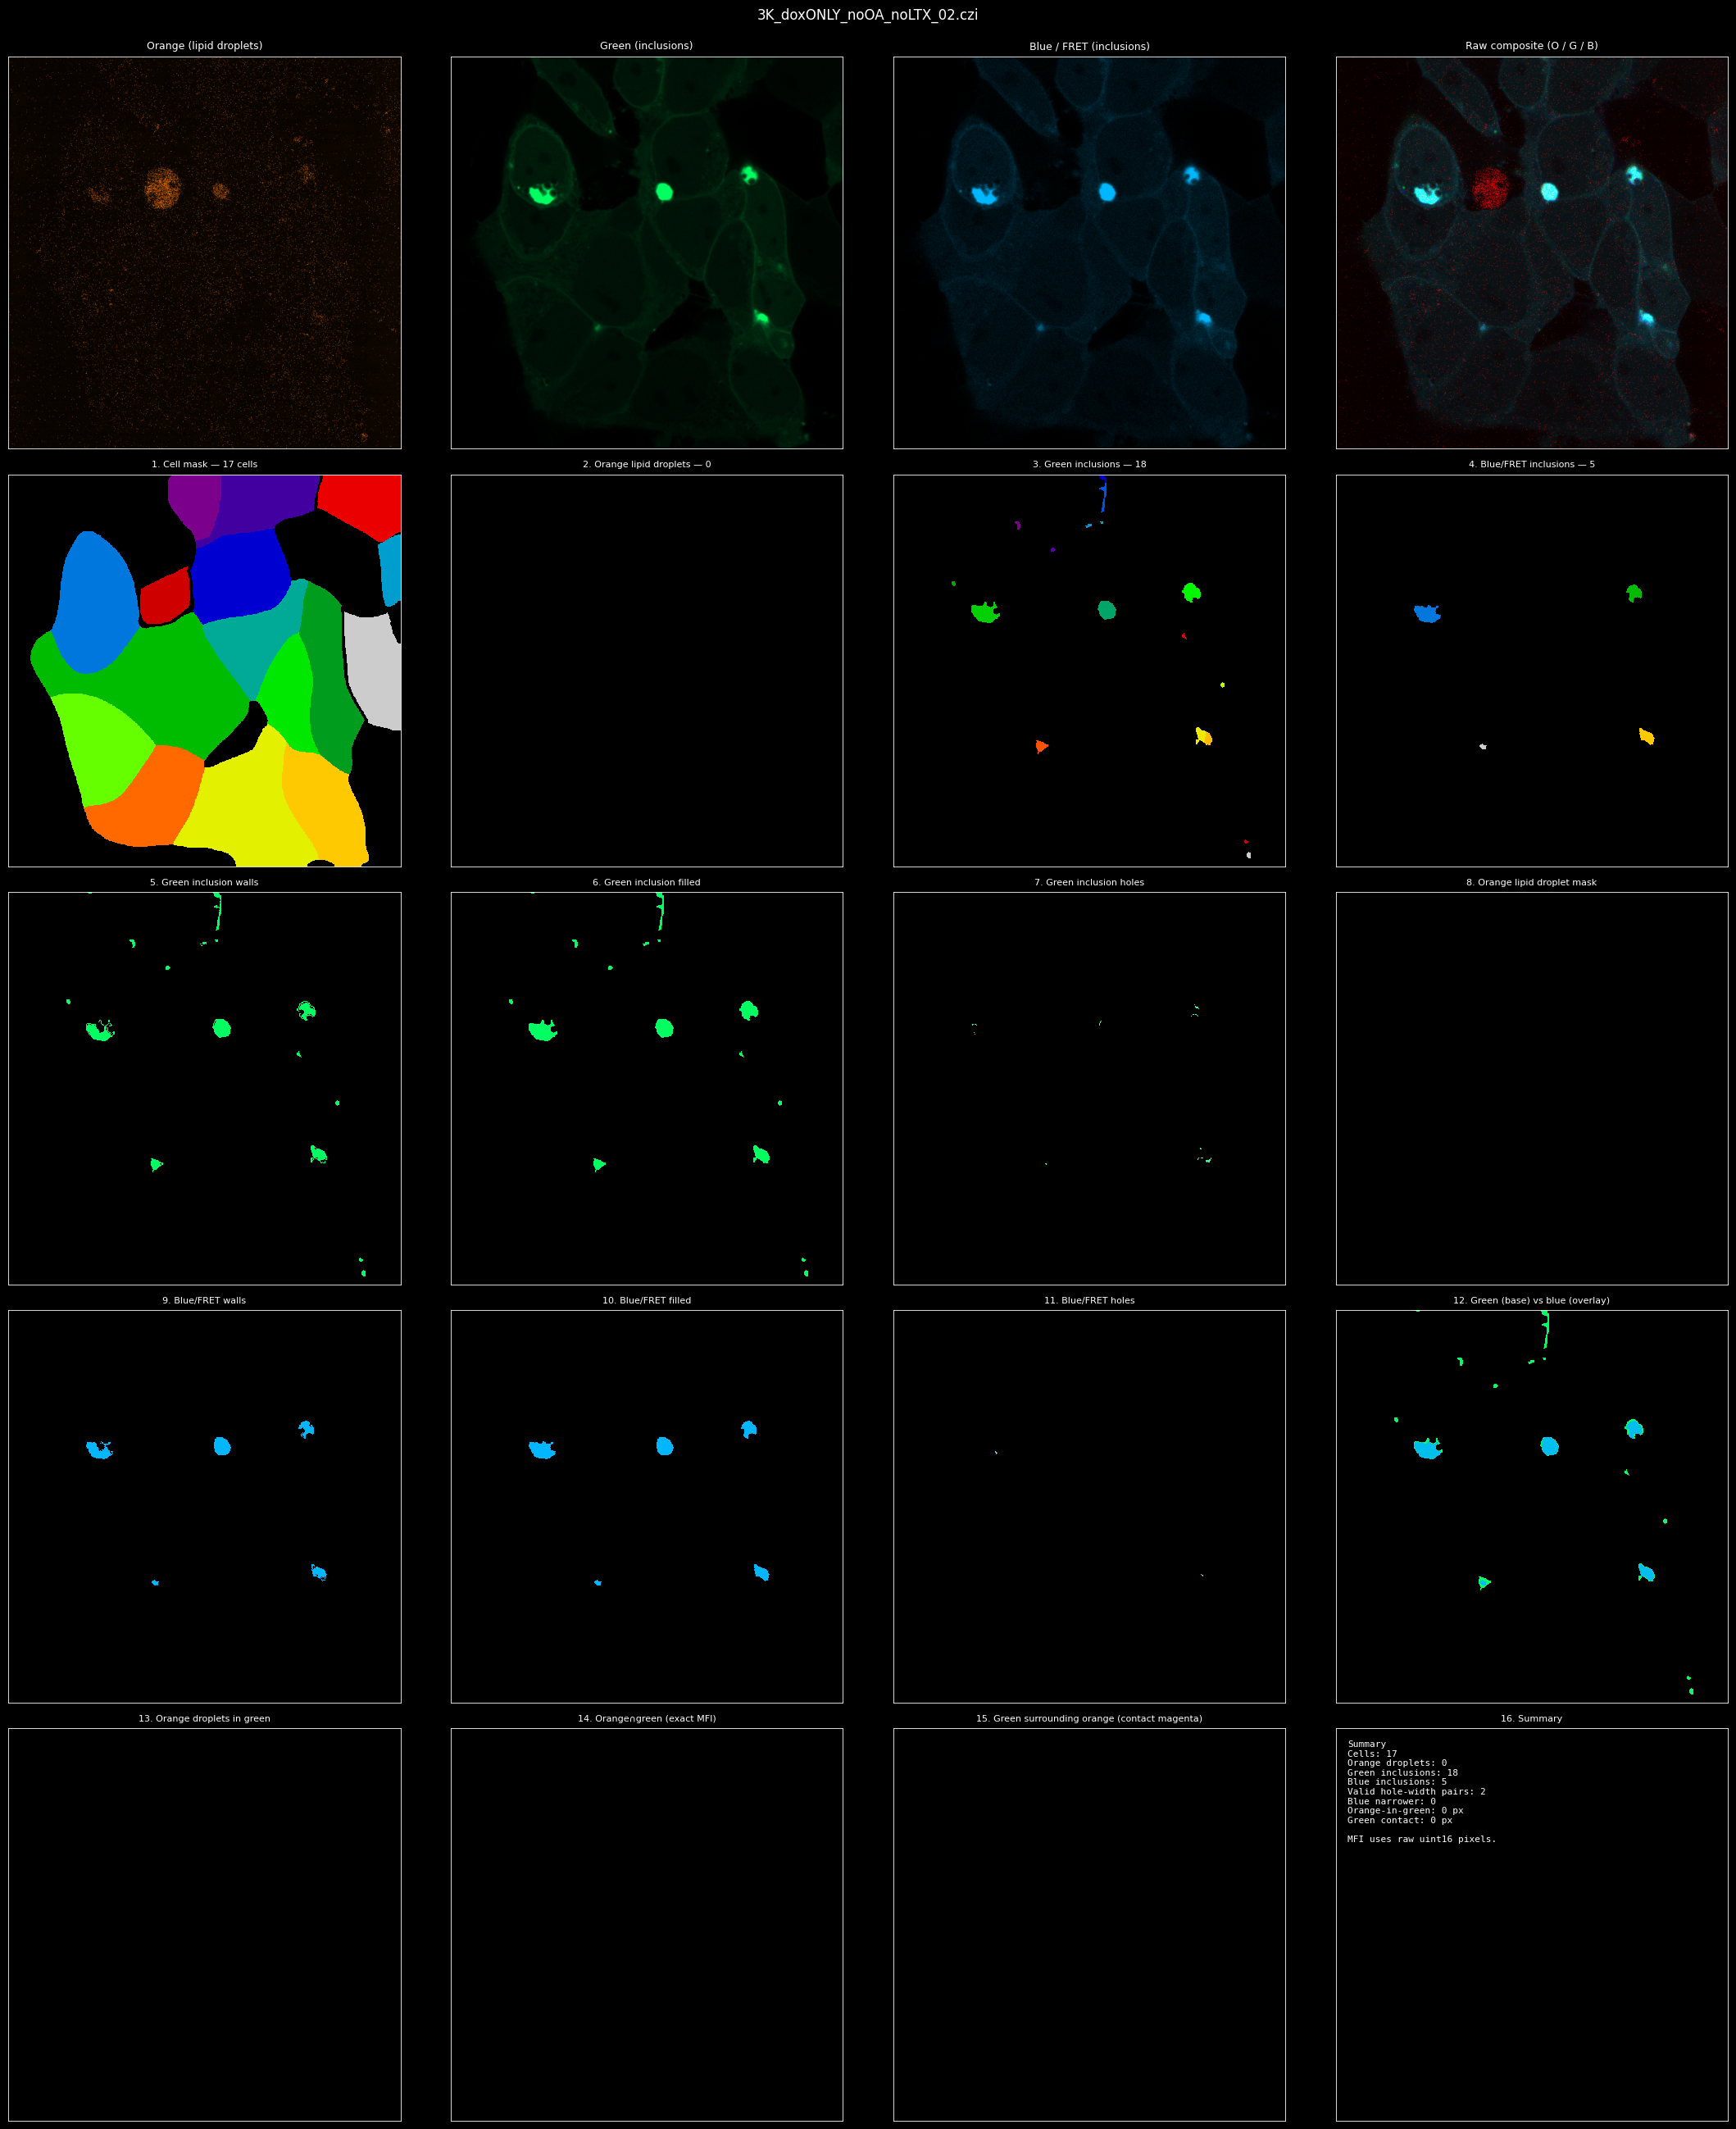


Analyzing 3K_doxONLY_noOA_noLTX_07.czi


  cells: 23


  green inclusions: 35; blue inclusions: 13


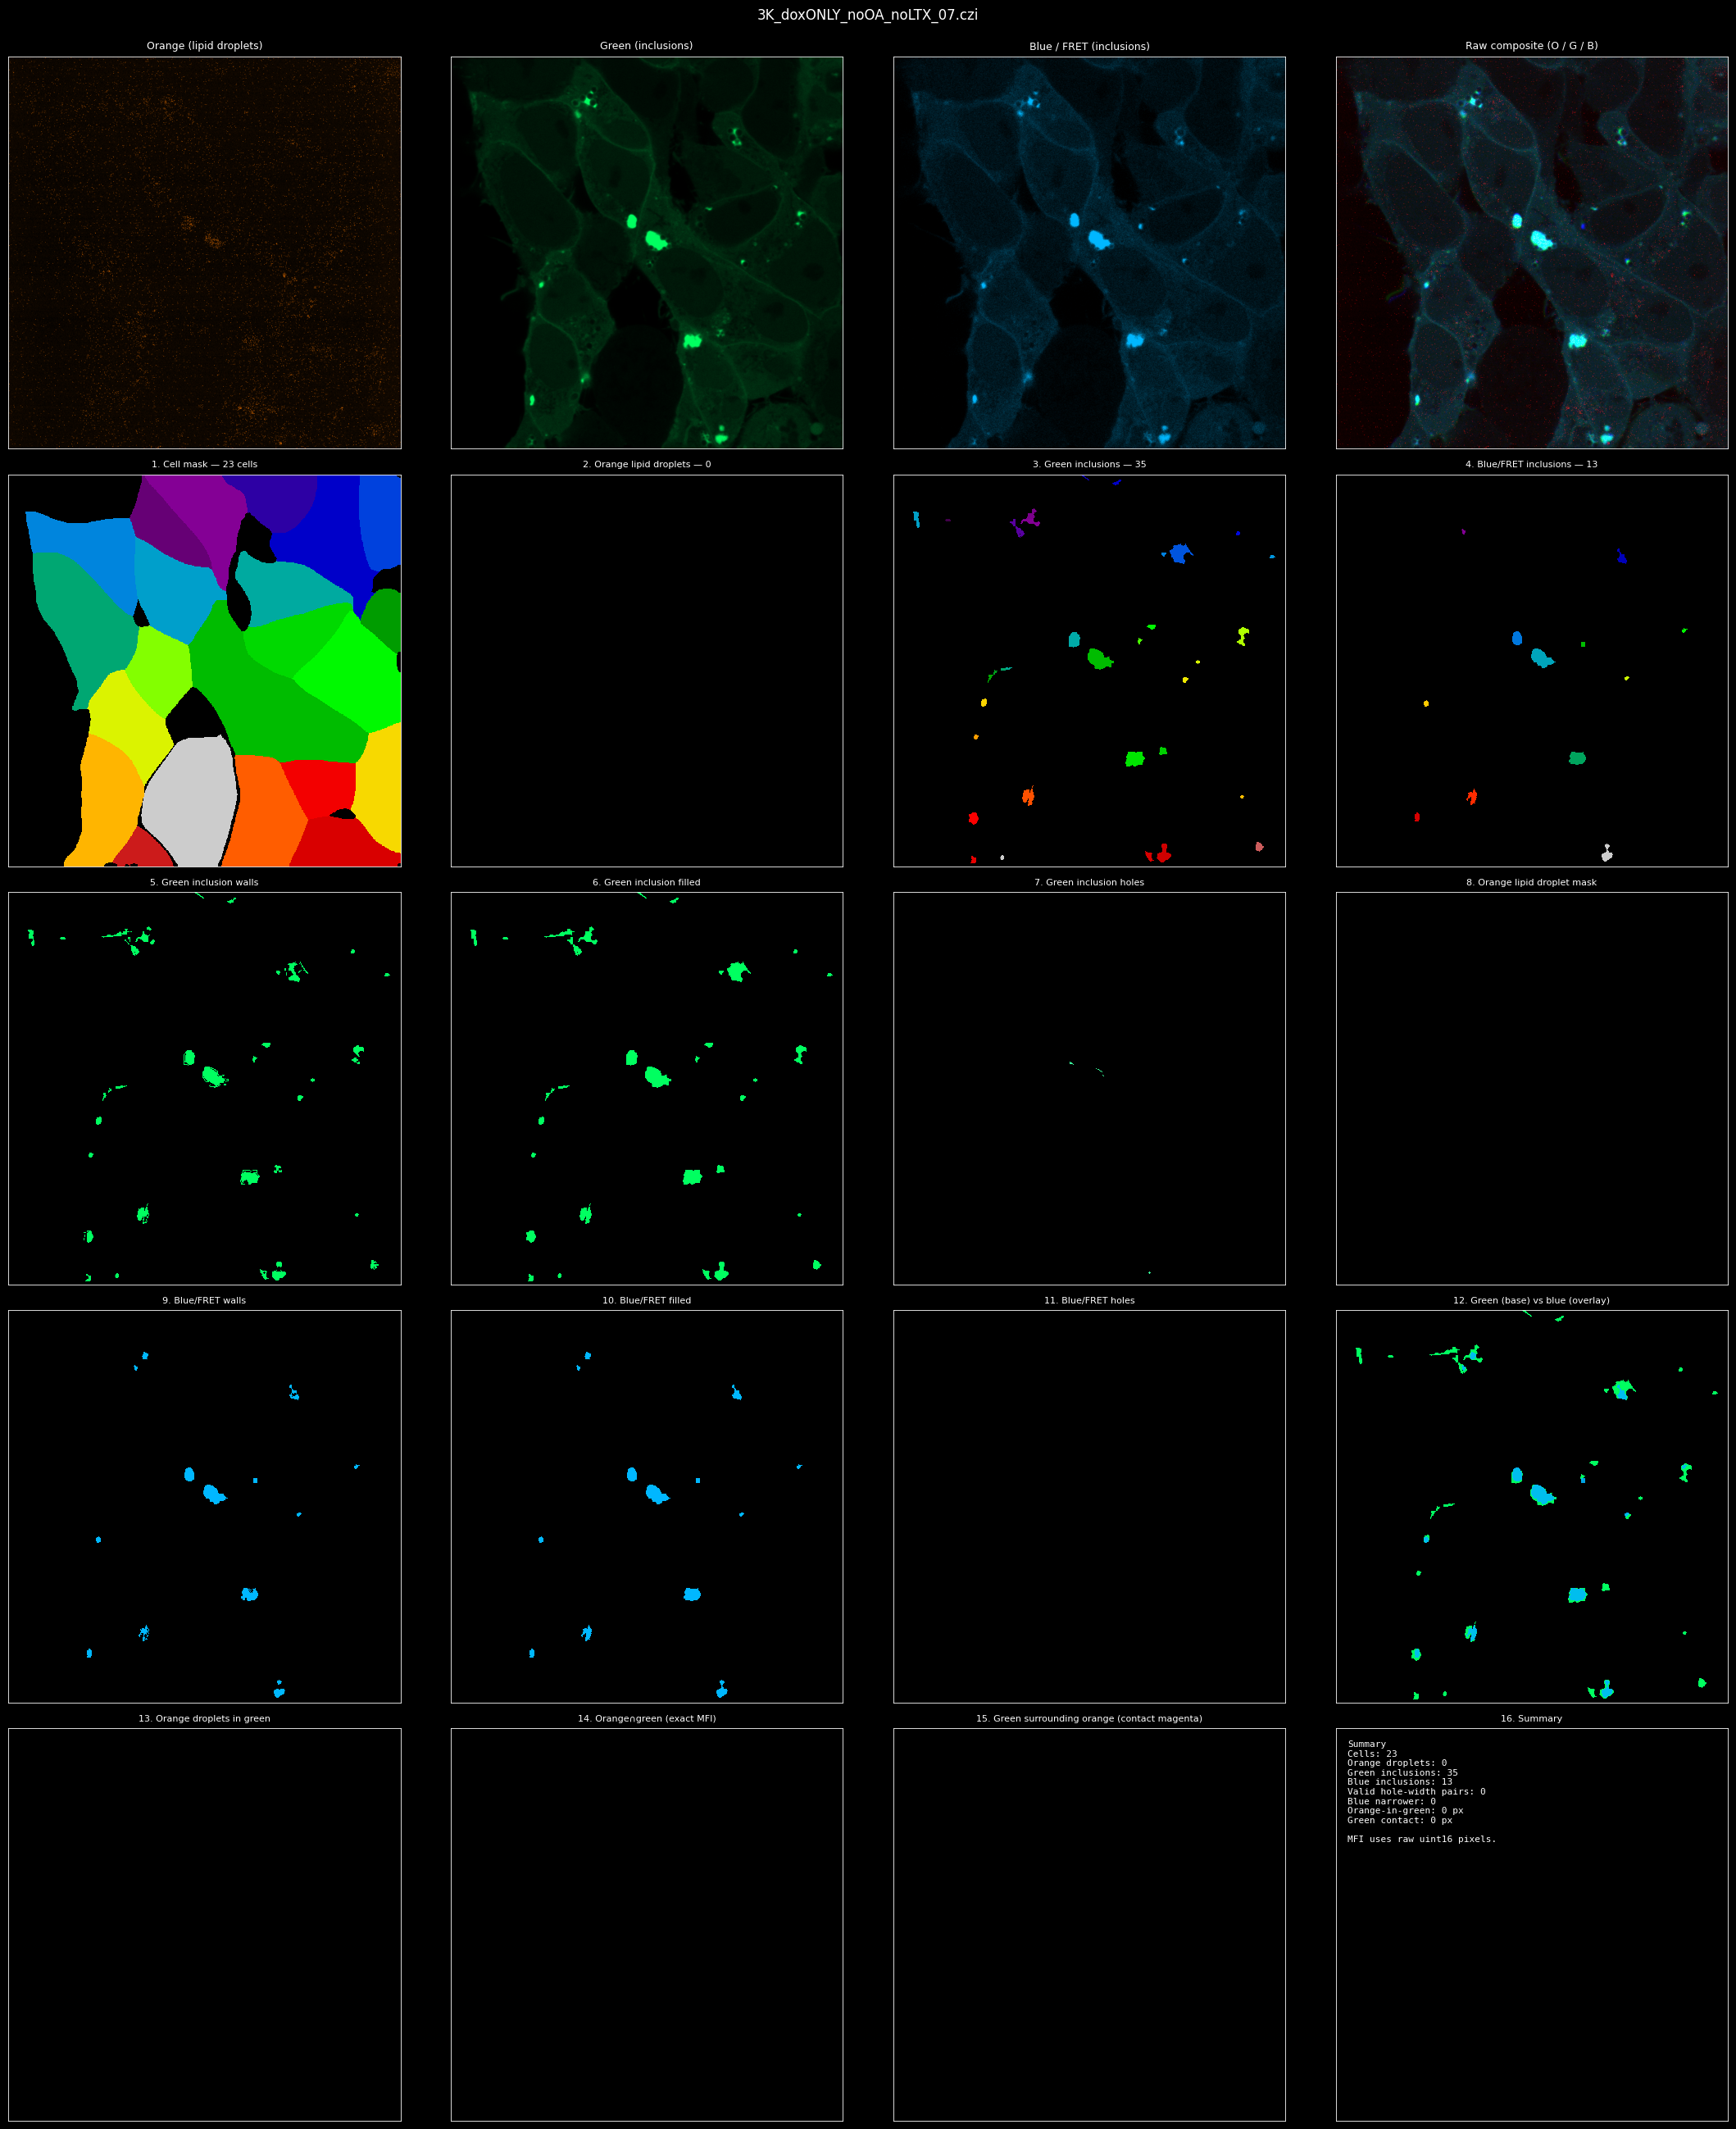


Analyzing 3K_dox_noOA_LipidToxRed_02.czi


  cells: 22


  green inclusions: 35; blue inclusions: 17


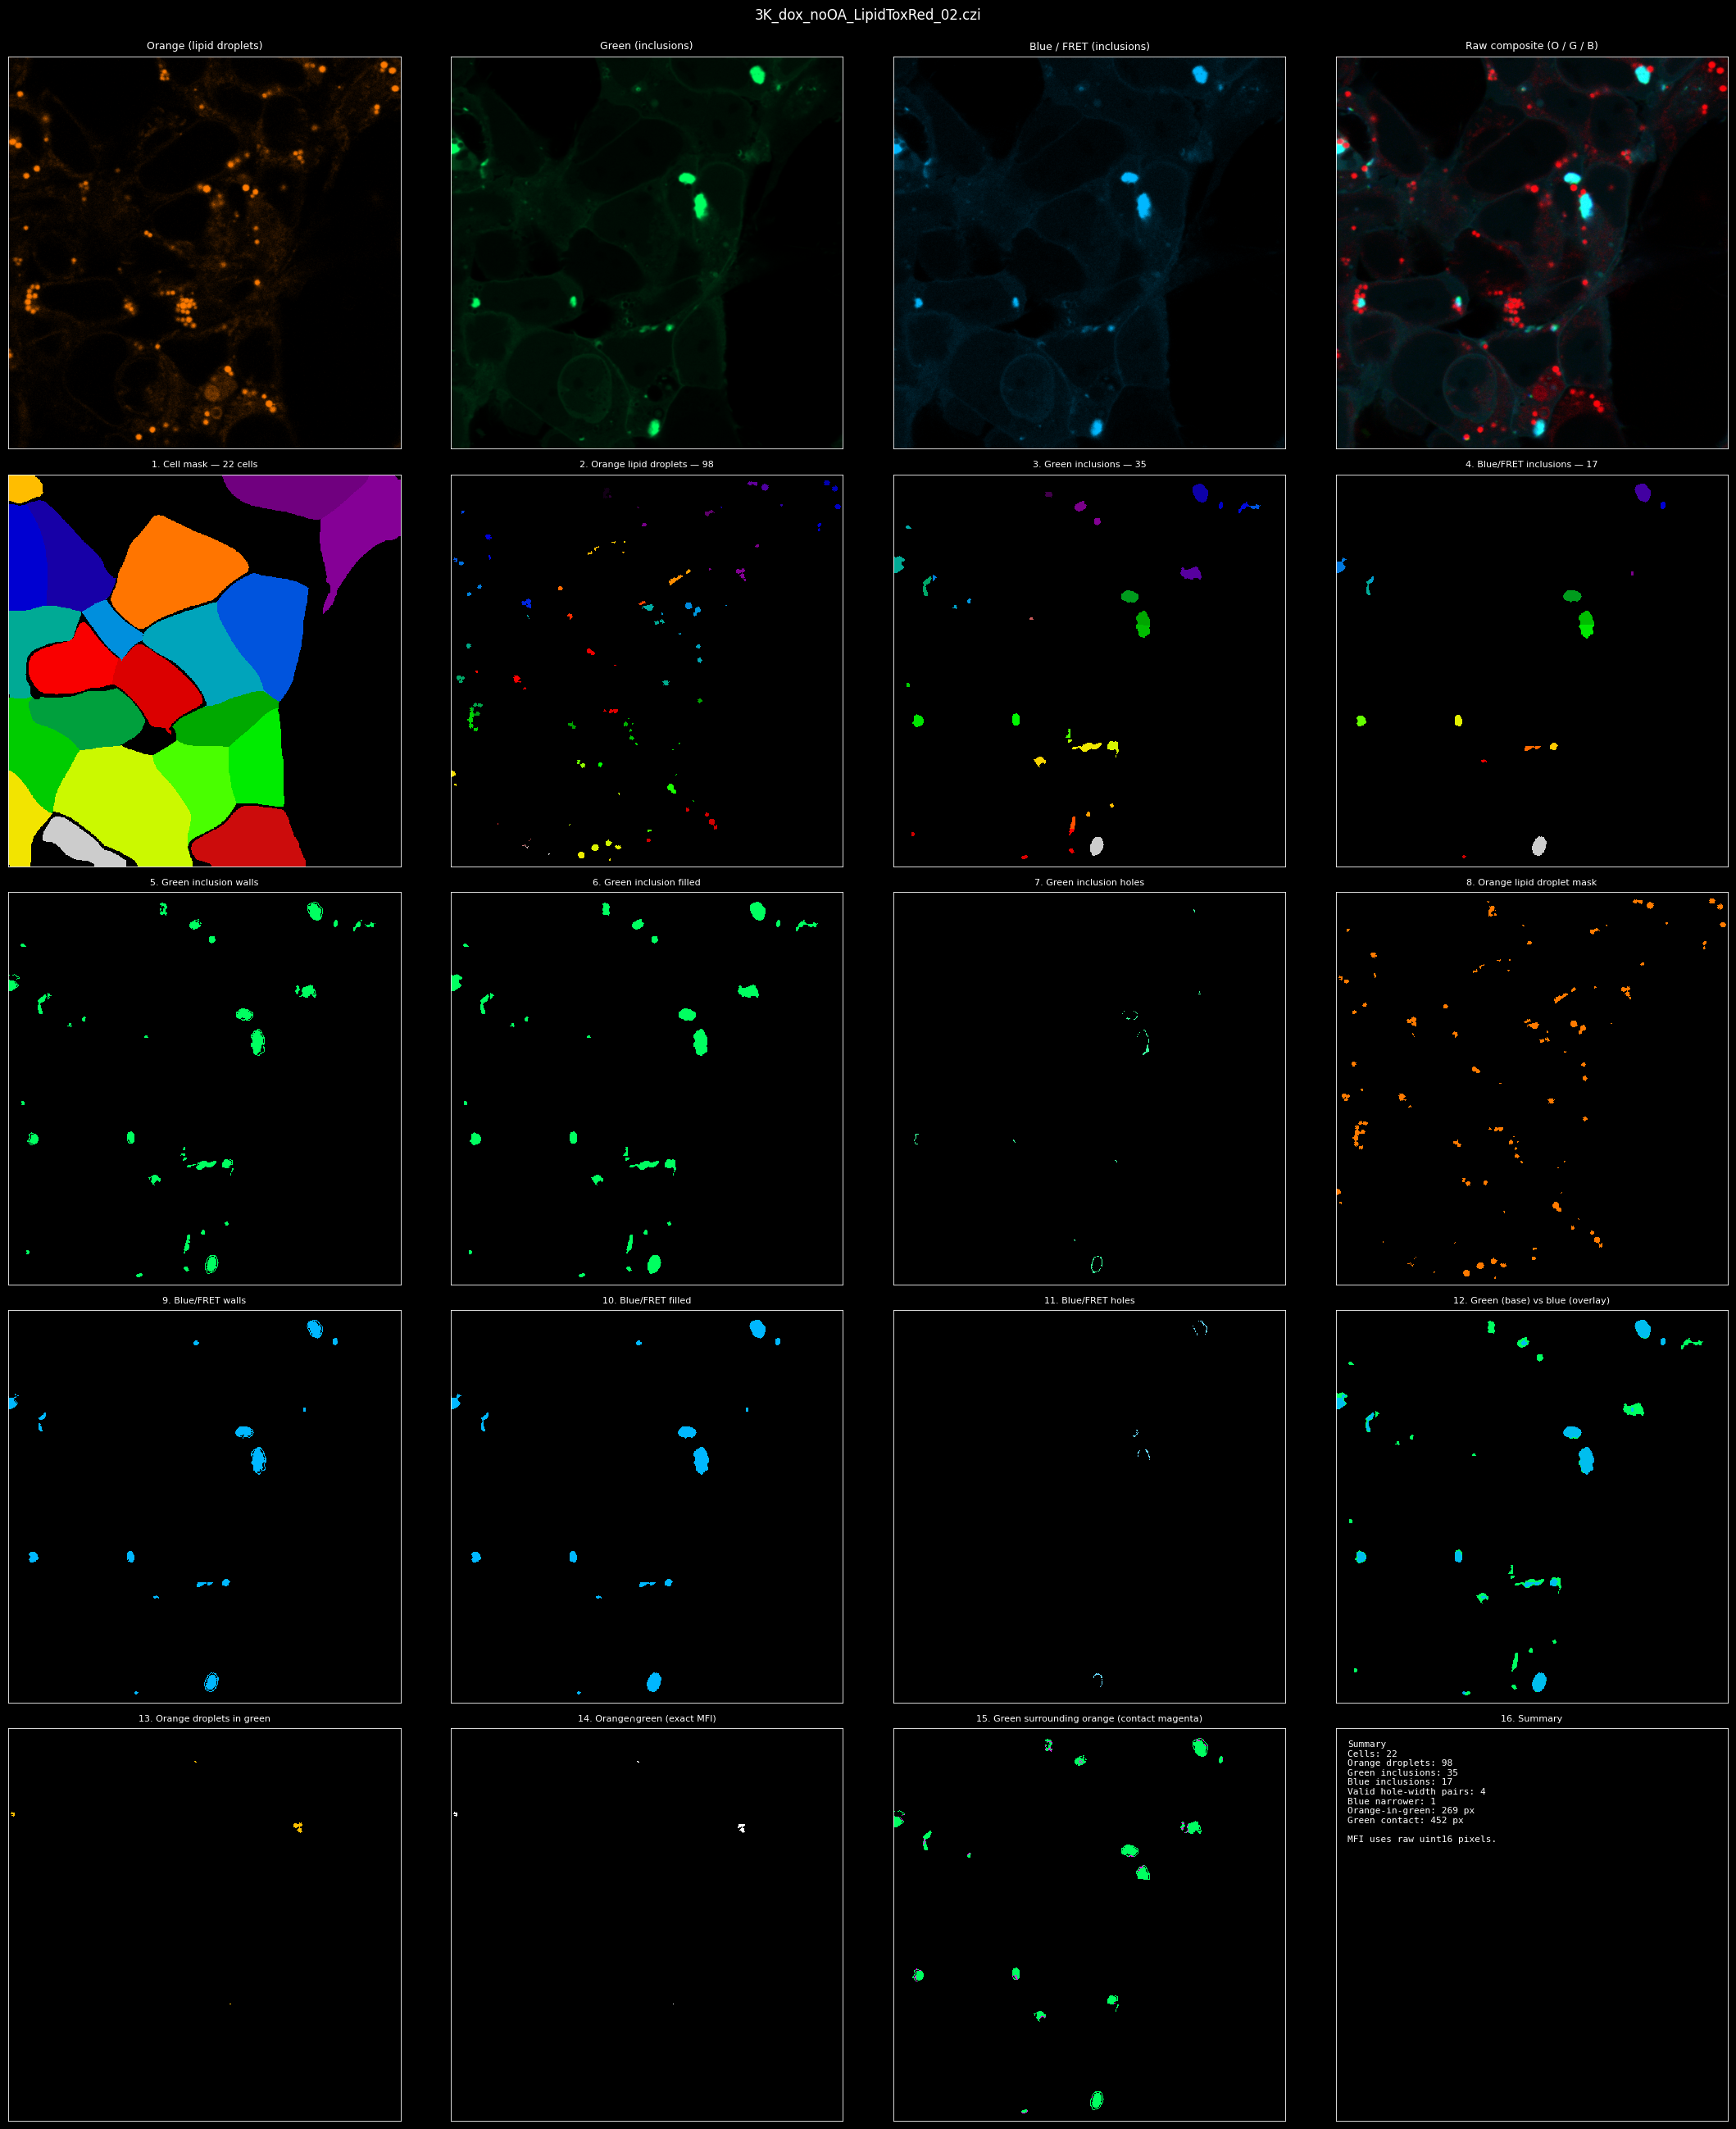


Analyzing 3K_dox_noOA_LipidToxRed_07.czi


  cells: 17


  green inclusions: 28; blue inclusions: 20


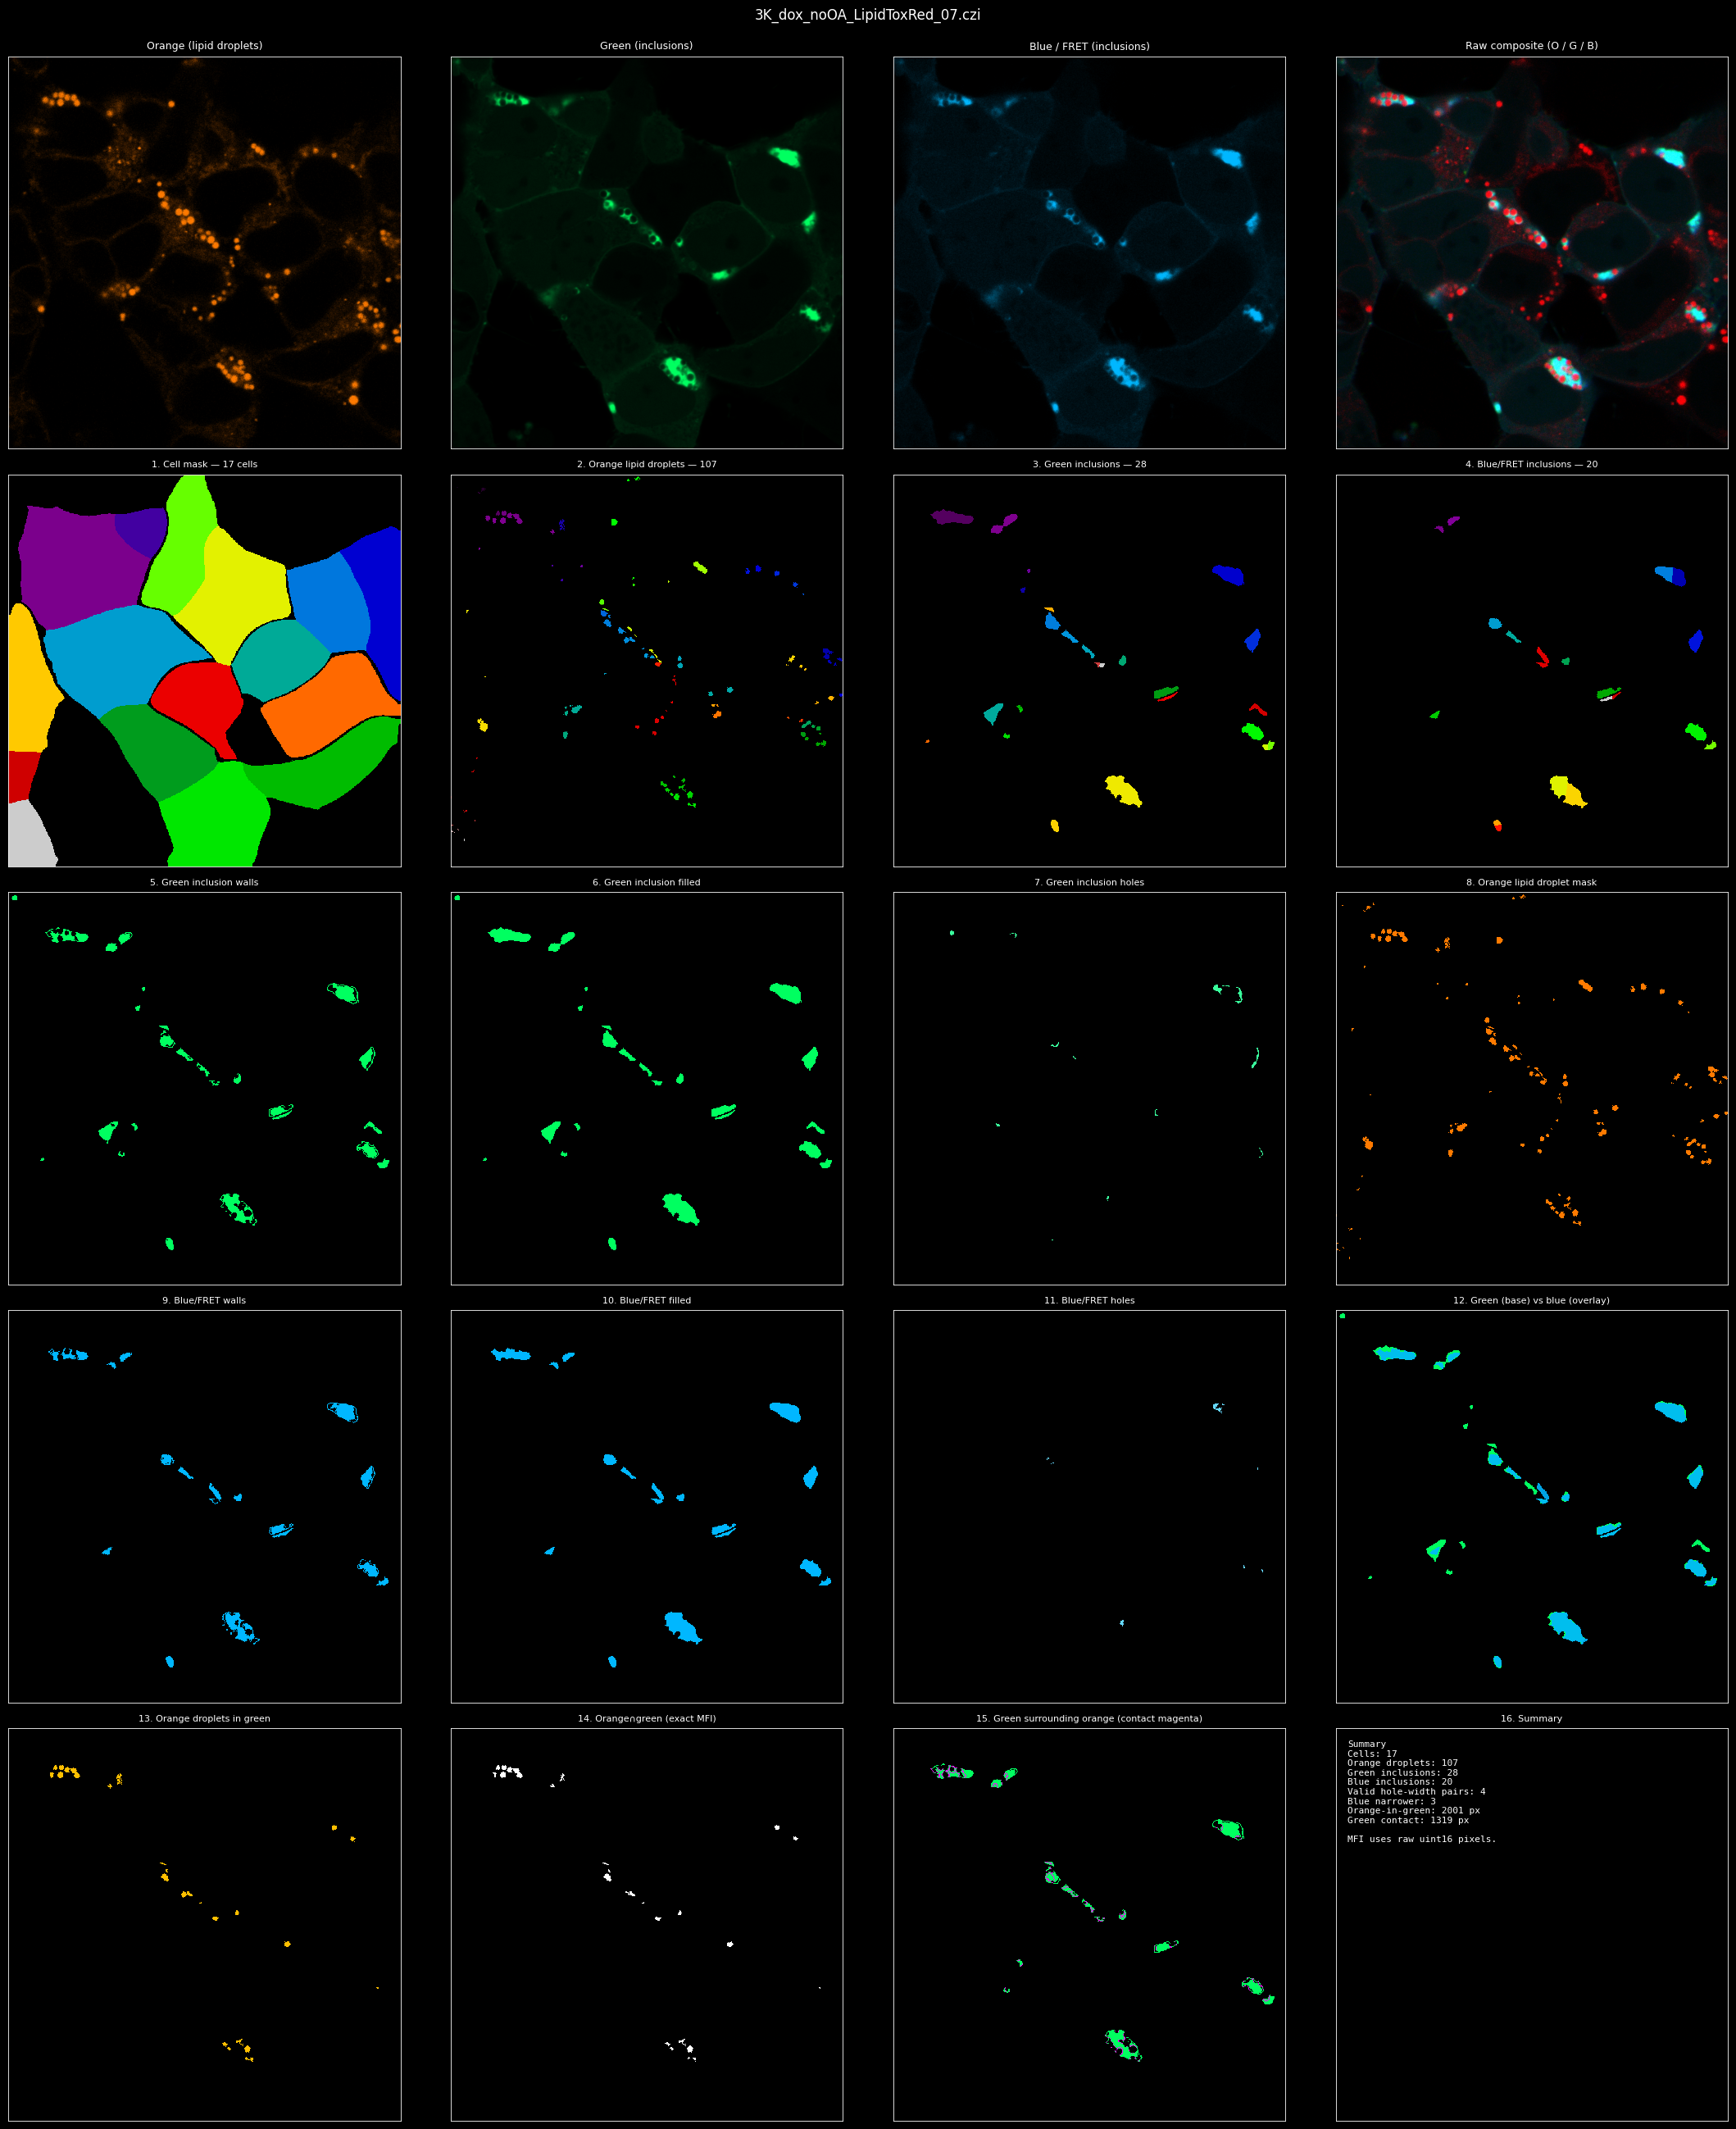


Done: 4 image(s), 79 cell row(s), 116 structure row(s).


,Image,Cells,Orange_Lipid_Droplets,Green_Inclusions,Blue_Inclusions,Matched_Green_Blue_Inclusions,Valid_Hole_Comparisons,Blue_Narrower_Count,Orange_Droplets_In_Green,Orange_Green_Intersection_Area_px,Green_Inclusions_Surrounding_Orange
0,3K_doxONLY_noOA_noLTX_02.czi,17,0,18,5,5,2,0,0,0,0
1,3K_doxONLY_noOA_noLTX_07.czi,23,0,35,13,13,0,0,0,0,0
2,3K_dox_noOA_LipidToxRed_02.czi,22,98,35,17,16,4,1,5,213,17
3,3K_dox_noOA_LipidToxRed_07.czi,17,107,28,20,16,4,3,24,1689,18


In [8]:
def analyze_folder(image_folder):
    """Segment every CZI in one folder and return its per-structure and
    per-cell rows plus per-image summaries (nothing is written here)."""
    folder_tag = os.path.basename(os.path.normpath(image_folder))
    mask_dir = os.path.join(MASK_FOLDER, folder_tag)
    os.makedirs(mask_dir, exist_ok=True)
    files = sorted(glob.glob(os.path.join(image_folder, FILE_EXTENSION)))
    print(f"---------- {folder_tag}: {len(files)} image(s) ----------")

    structure_rows, cell_rows, summaries = [], [], []
    for filepath in files:
        bundle = segment_one_image(filepath, mask_dir)
        structure_rows.extend(bundle["structure_records"])
        for cid in range(1, int(bundle["labeled_cells"].max()) + 1):
            cell_rows.append(
                analyze_cell(cid, os.path.basename(filepath),
                             bundle["raw"], bundle["labeled_cells"], bundle["masks"])
            )
        summaries.append(bundle["per_image_summary"])
    return structure_rows, cell_rows, summaries


ALL_STRUCTURES, ALL_CELLS, ALL_SUMMARIES = [], [], []
for image_folder in IMAGE_FOLDERS:
    if not os.path.isdir(image_folder):
        print(f"[skip] {image_folder} not found")
        continue
    s_rows, c_rows, m_rows = analyze_folder(image_folder)
    ALL_STRUCTURES += s_rows
    ALL_CELLS += c_rows
    ALL_SUMMARIES += m_rows

structures_df = pd.DataFrame(ALL_STRUCTURES, columns=STRUCTURE_COLUMNS)
cells_df = pd.DataFrame(ALL_CELLS, columns=CELL_COLUMNS)
summary_df = pd.DataFrame(ALL_SUMMARIES)
print(f"\nDone: {len(ALL_SUMMARIES)} image(s), "
      f"{len(cells_df)} cell row(s), {len(structures_df)} structure row(s).")
summary_df


## Output summary

In [9]:
# Write the two spreadsheets from the results collected above, then report.
def write_outputs(structure_records, cell_records, summaries):
    """Write the per-structure and per-cell spreadsheets (one image-summary tab each)."""
    structures = pd.DataFrame(structure_records, columns=STRUCTURE_COLUMNS)
    cells = pd.DataFrame(cell_records, columns=CELL_COLUMNS)
    summary = pd.DataFrame(summaries)
    os.makedirs(RESULTS_FOLDER, exist_ok=True)

    structure_path = os.path.join(RESULTS_FOLDER, "3k_FRET_structure_hole_comparison.xlsx")
    cell_path = os.path.join(RESULTS_FOLDER, "3k_FRET_per_cell_raw_MFI.xlsx")
    with pd.ExcelWriter(structure_path) as writer:
        structures.to_excel(writer, sheet_name="Structure comparison", index=False)
        summary.to_excel(writer, sheet_name="Image summary", index=False)
    with pd.ExcelWriter(cell_path) as writer:
        cells.to_excel(writer, sheet_name="Per-cell raw MFI", index=False)
        summary.to_excel(writer, sheet_name="Image summary", index=False)
    return structure_path, cell_path


structure_path, cell_path = write_outputs(ALL_STRUCTURES, ALL_CELLS, ALL_SUMMARIES)
print(f"{len(ALL_SUMMARIES)} image(s); masks in {MASK_FOLDER}/<folder>/<image>/")
print(f"  {structure_path}  ({len(structures_df)} structure rows)")
print(f"  {cell_path}  ({len(cells_df)} cell rows)")


4 image(s); masks in Results/masks/<folder>/<image>/
  Results/3k_FRET_structure_hole_comparison.xlsx  (116 structure rows)
  Results/3k_FRET_per_cell_raw_MFI.xlsx  (79 cell rows)
